In [1]:
from Scripts.Random_forest_nested import *
import pickle
import matplotlib.pyplot as plt
from scipy.stats import randint
import seaborn as sns
import pandas as pd
import shap
import matplotlib.patheffects as pe
import numpy as np


In [2]:
df = pd.read_excel('../Data_preprocessing/all_time.xlsx', index_col=0)
X,y=df.loc[:,['scaled_nox', 'scaled_no2', 'scaled_formaldehyd', 'scaled_acetone',
       'scaled_acetald', 'scaled_bc', 'scaled_PM25', 'no2_street', 'nox_street',
       'pm25_street', 'bmi_6_yrs', 'gestational_age', 'mother\'s_education_1yr',"lrti_1y",
        'genetic_risk_score_asthma', 'PCA1', 'PCA2']],df.asthma_0_7yrs


In [3]:
list_parameters=[r'$\mathbf{NO_x}$',r'$\mathbf{NO_2}$',"Formaldehyd","Acetone","Acetald","Black Carbon",r'$\mathbf{PM_{2.5}}$',r"$\mathbf{Street \ NO_2}$",r"$\mathbf{Street \ NO_x}$",r"$\mathbf{Street \ PM_{2.5}}$","BMI","Gestational age","Mother Education","LRTI","PRS","PC 1","PC 2"]


In [4]:
replace_dict=dict(zip(X.columns,list_parameters))
X=X.rename(columns=replace_dict)

In [5]:
param_distributions = {
    'n_estimators':           [300],
    'max_depth':              randint(2, 6),
    'min_samples_leaf':       randint(5, 15),
    'max_features':           [0.5, 0.6, 0.7],
    'max_samples':            [0.5, 0.6, 0.7],
    # class_weight removed
}
dataframe=nested_cv_calibrated_rf(
    X, y,
    n_repeats=5,
    n_splits=5,
    n_neighbors_imputer=25,
    param_distributions=param_distributions)

/data/michaelf/miniconda3/envs/clinical_regression/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/data/michaelf/miniconda3/envs/clinical_regression/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/data/michaelf/miniconda3/envs/clinical_regression/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

fold   1/25  test AUC=0.722  BSS=+0.071  ICI=0.046   | apparent AUC=0.864
fold   2/25  test AUC=0.784  BSS=+0.139  ICI=0.068   | apparent AUC=0.873
fold   3/25  test AUC=0.692  BSS=+0.087  ICI=0.045   | apparent AUC=0.874
fold   4/25  test AUC=0.534  BSS=-0.002  ICI=0.060   | apparent AUC=0.860
fold   5/25  test AUC=0.607  BSS=+0.007  ICI=0.043   | apparent AUC=0.899
fold   6/25  test AUC=0.669  BSS=+0.045  ICI=0.045   | apparent AUC=0.832
fold   7/25  test AUC=0.807  BSS=+0.074  ICI=0.106   | apparent AUC=0.846
fold   8/25  test AUC=0.578  BSS=+0.008  ICI=0.041   | apparent AUC=0.831
fold   9/25  test AUC=0.663  BSS=+0.045  ICI=0.024   | apparent AUC=0.906
fold  10/25  test AUC=0.700  BSS=+0.098  ICI=0.057   | apparent AUC=0.906
fold  11/25  test AUC=0.640  BSS=+0.038  ICI=0.026   | apparent AUC=0.974
fold  12/25  test AUC=0.664  BSS=+0.060  ICI=0.054   | apparent AUC=0.887
fold  13/25  test AUC=0.578  BSS=+0.035  ICI=0.057   | apparent AUC=0.928
fold  14/25  test AUC=0.616  BSS=+0.00

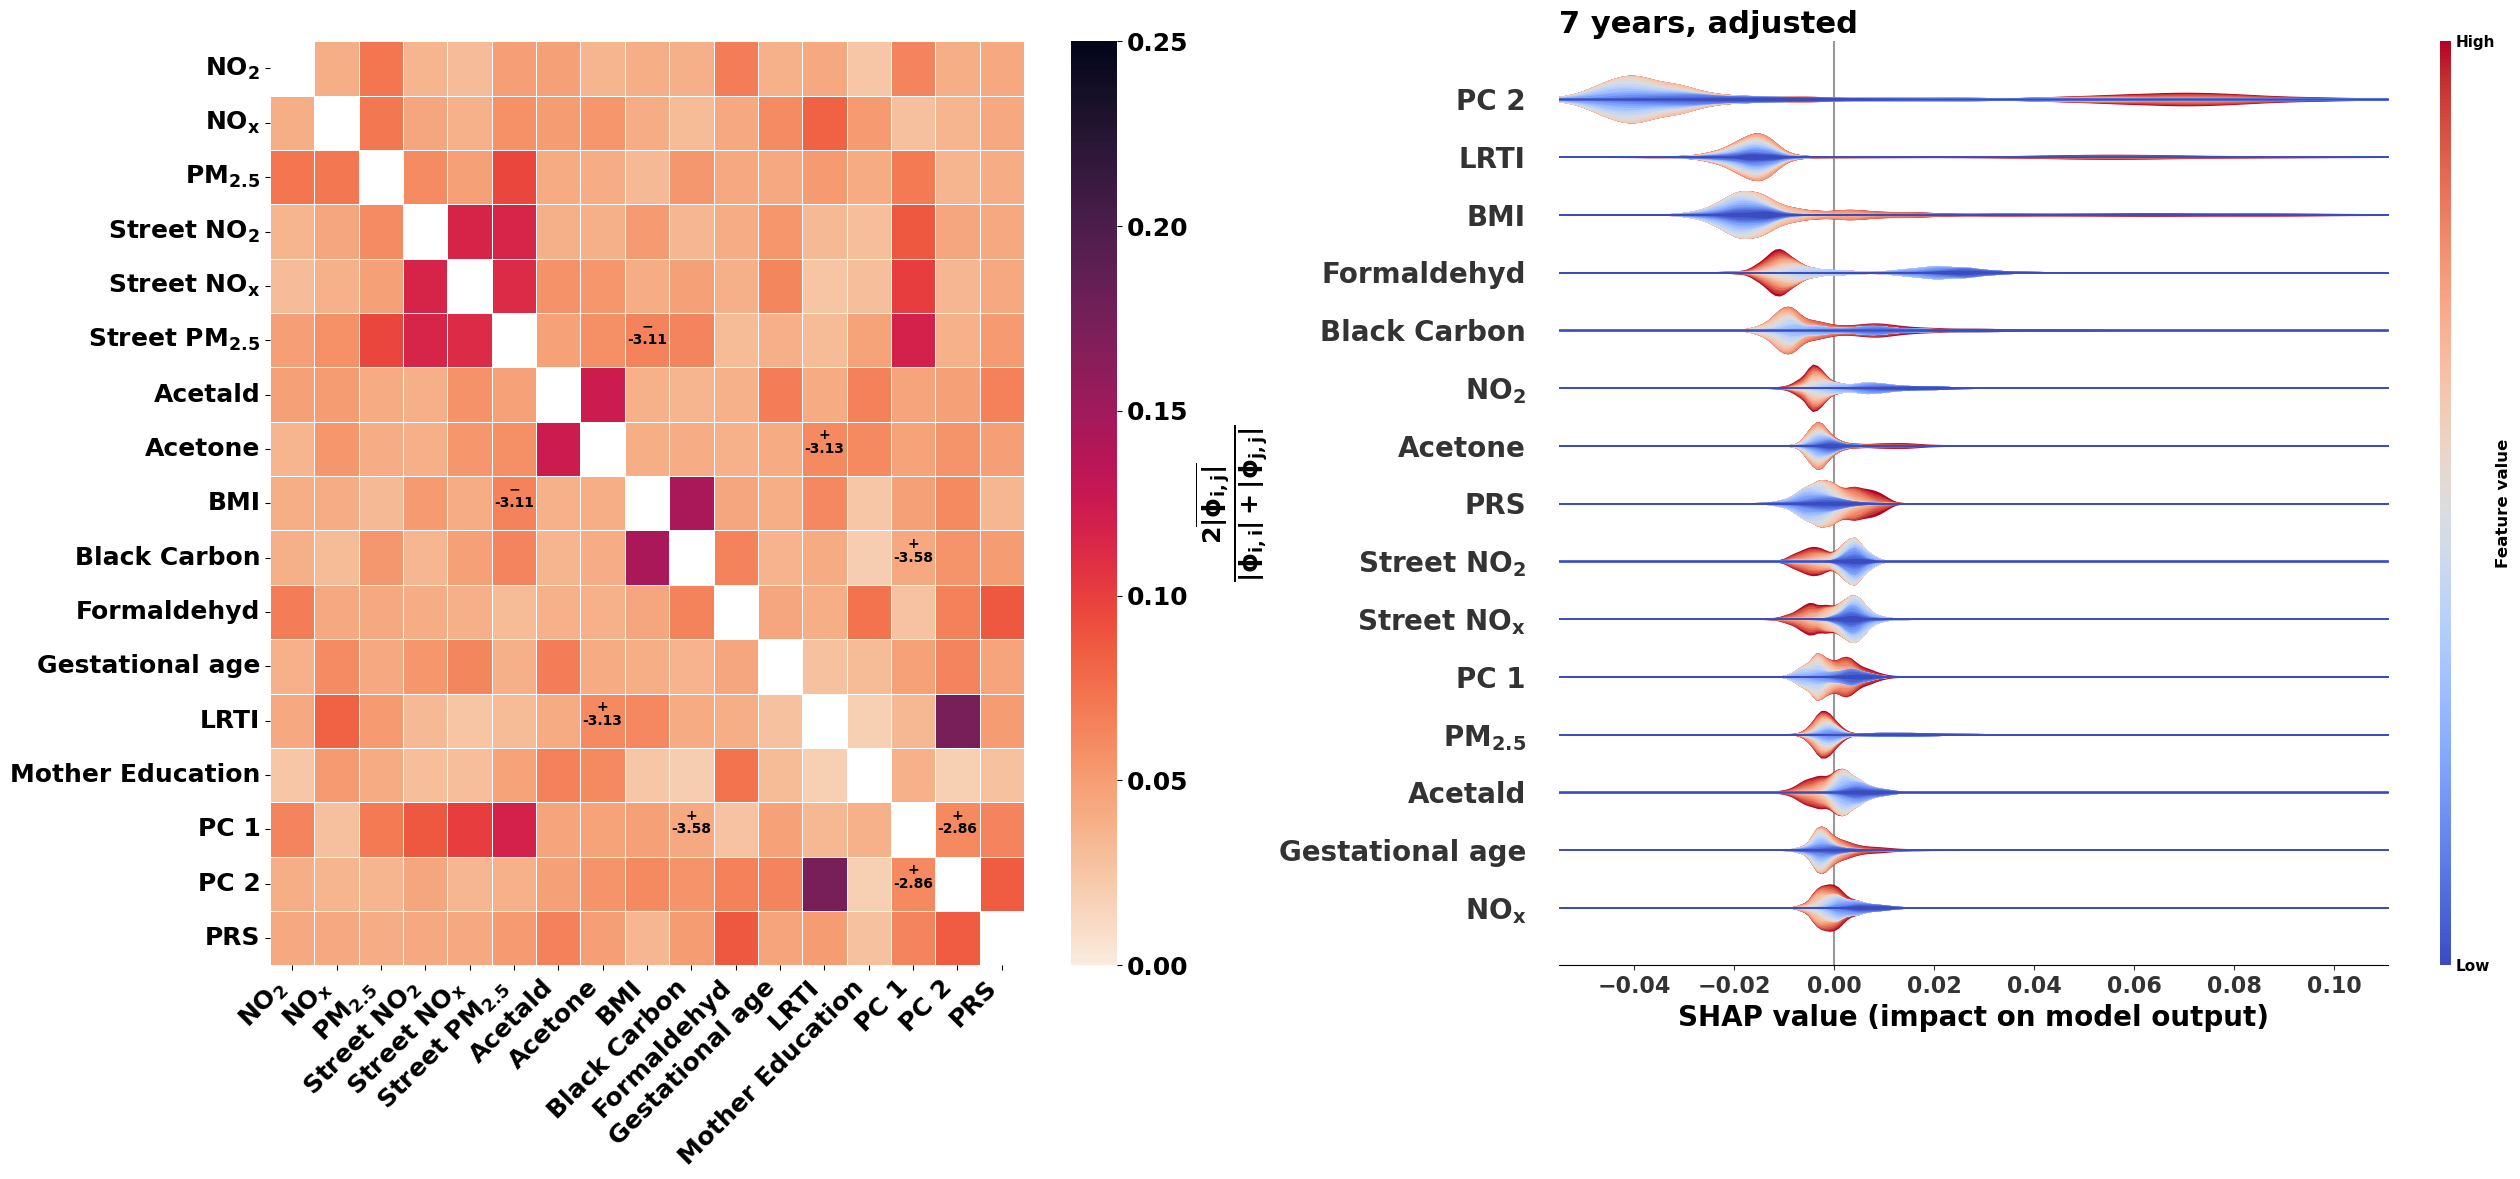

In [6]:

# Swap the columns to create the reverse relationships (B->A, C->A, C->B)
df_flipped = dataframe["interaction_stats"].rename(columns={'feature_i': 'feature_j', 'feature_j': 'feature_i'})

# Combine them together
df_full = pd.concat([dataframe["interaction_stats"], df_flipped]).drop_duplicates()
features_to_drop = ["feature_i", "feature_j"]

matrix_r = df_full.pivot(index='feature_i', columns='feature_j', values='R_mean').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_con = df_full.pivot(index='feature_i', columns='feature_j', values='sign_consistency').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_effect = df_full.pivot(index='feature_i', columns='feature_j', values='abs_2phi_median').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_effect_sign = df_full.pivot(index='feature_i', columns='feature_j', values='signed_2phi_median').rename_axis(None, axis=0).rename_axis(None, axis=1)
dominant_sign= df_full.pivot(index='feature_i', columns='feature_j', values='dominant_sign').rename_axis(None, axis=0).rename_axis(None, axis=1)
plt.rcParams.update({
    "mathtext.default":  "bf",
    "font.weight":       "bold",
    "axes.labelweight":  "bold",
    "axes.titleweight":  "bold",
    "figure.titleweight":"bold",
})
corr_matrix=X.corr(method="spearman")
k = matrix_r.shape[0]

fig = plt.figure(figsize=(30, 12))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1], wspace=0.35)
ax0, ax1 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

hm = sns.heatmap(matrix_r, cmap="rocket_r", vmin=0, vmax=0.25,
                 linewidths=0.4, linecolor="white", ax=ax0,
                 cbar_kws={'label': r'$\frac{2\overline{|\phi_{i,j}|}}{|\phi_{i,i}|+|\phi_{j,j}|}$'})

norm, cmap = hm.collections[0].norm, hm.collections[0].cmap
for i in range(k):
    for j in range(k):                            # lower triangle only
        if matrix_con.iloc[i, j] < 0.8:
            continue
        if i==j:
            continue
        if matrix_con.iloc[i, j] < 0.8:
            continue   
        val = matrix_effect.iloc[i, j]
        sgn = "+" if dominant_sign.iloc[i, j] >= 0 else "\u2212"
        r, g, b, _ = cmap(norm(matrix_r.iloc[i, j]))
        ax0.text(j + 0.5, i + 0.5, f"{np.log10(val):.2f}", ha="center", va="center",  fontsize=10, fontweight="bold")
        ax0.text(j + 0.5, i + 0.25, f"{sgn}", ha="center", va="center",
                 fontsize=10, fontweight="bold")      

# ---- heatmap ticks ----
ax0.tick_params(axis="both", labelsize=18)
plt.setp(ax0.get_xticklabels(), rotation=45, ha="right", fontsize=18, fontweight="bold")
plt.setp(ax0.get_yticklabels(), fontsize=18, fontweight="bold")

# ---- colorbar ----
cbar = hm.collections[0].colorbar
cbar.ax.yaxis.label.set(size=26, weight="bold")
cbar.ax.tick_params(labelsize=18)
plt.setp(cbar.ax.get_yticklabels(), fontweight="bold")

# ---- shap panel ----
plt.sca(ax1)
shap.plots.violin(dataframe["shap_explanation"],
                  plot_type="layered_violin",
                  max_display=15, show=False, plot_size=None)
ax1.tick_params(axis="y", labelsize=20)
ax1.tick_params(axis="x", labelsize=16)
plt.setp(ax1.get_yticklabels(), fontsize=20, fontweight="bold")
plt.setp(ax1.get_xticklabels(), fontsize=16, fontweight="bold")
ax1.set_xlabel(ax1.get_xlabel(), fontsize=20, fontweight="bold")
ax1.set_title("7 years, adjusted", loc="left", fontsize=22, pad=6, fontweight="bold")

fig.savefig("../Plots/shap_7_adjusted.png", bbox_inches="tight",dpi=300)  

In [9]:
with open("../Data_preprocessing/results_rf_7y_adjusted.pkl", "wb") as f:
    pickle.dump(dataframe, f)

In [7]:
corr_matrix

,$\mathbf{NO_x}$,$\mathbf{NO_2}$,Formaldehyd,Acetone,Acetald,Black Carbon,$\mathbf{PM_{2.5}}$,$\mathbf{Street \ NO_2}$,$\mathbf{Street \ NO_x}$,$\mathbf{Street \ PM_{2.5}}$,BMI,Gestational age,Mother Education,LRTI,PRS,PC 1,PC 2
$\mathbf{NO_x}$,1.000000,0.434647,0.098047,0.149402,0.217810,0.268199,0.198716,0.219422,0.201172,0.095533,-0.018886,-0.057779,0.011660,-0.057656,0.022075,0.237978,-0.083210
$\mathbf{NO_2}$,0.434647,1.000000,-0.207546,0.045815,0.096530,0.418746,0.339578,0.395745,0.358060,0.200148,0.009422,-0.017688,0.064424,-0.029292,0.029960,0.530802,0.008736
Formaldehyd,0.098047,-0.207546,1.000000,-0.001098,-0.022664,0.013386,-0.046808,-0.154550,-0.148004,-0.049902,-0.029450,0.017418,-0.091599,-0.071925,0.051719,-0.253049,0.110506
Acetone,0.149402,0.045815,-0.001098,1.000000,0.857171,-0.071893,0.032886,0.032400,0.032781,0.131659,0.037336,0.007256,0.014182,-0.071676,0.048219,-0.030687,-0.010624
Acetald,0.217810,0.096530,-0.022664,0.857171,1.000000,0.017110,0.163192,0.023286,0.027403,0.099687,0.073238,0.020670,0.014465,-0.063321,0.024869,0.008631,-0.059682
Black Carbon,0.268199,0.418746,0.013386,-0.071893,0.017110,1.000000,0.703906,0.172093,0.181072,0.104110,-0.067138,-0.150354,-0.130560,-0.038495,0.011137,0.291316,-0.124963
$\mathbf{PM_{2.5}}$,0.198716,0.339578,-0.046808,0.032886,0.163192,0.703906,1.000000,0.102712,0.113916,0.043203,0.085932,-0.088263,-0.209911,0.025916,-0.026113,0.260886,-0.145196
$\mathbf{Street \ NO_2}$,0.219422,0.395745,-0.154550,0.032400,0.023286,0.172093,0.102712,1.000000,0.973919,0.746800,-0.003796,-0.064769,0.153923,-0.079334,0.069685,0.576069,0.085201
$\mathbf{Street \ NO_x}$,0.201172,0.358060,-0.148004,0.032781,0.027403,0.181072,0.113916,0.973919,1.000000,0.759560,0.002402,-0.053754,0.144825,-0.070719,0.084747,0.520874,0.045216
$\mathbf{Street \ PM_{2.5}}$,0.095533,0.200148,-0.049902,0.131659,0.099687,0.104110,0.043203,0.746800,0.759560,1.000000,0.017196,-0.039423,0.145176,-0.071373,0.107362,0.353559,-0.033414
